# Matplotlib

In [1]:
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Load the dataset
dataset, info = tfds.load(
    'oxford_iiit_pet', split="train", with_info=True, as_supervised=True
)

print("Number of classes in dataset:", info.features['label'].num_classes)

Number of classes in dataset: 37


### Display images from tensorflow dataset

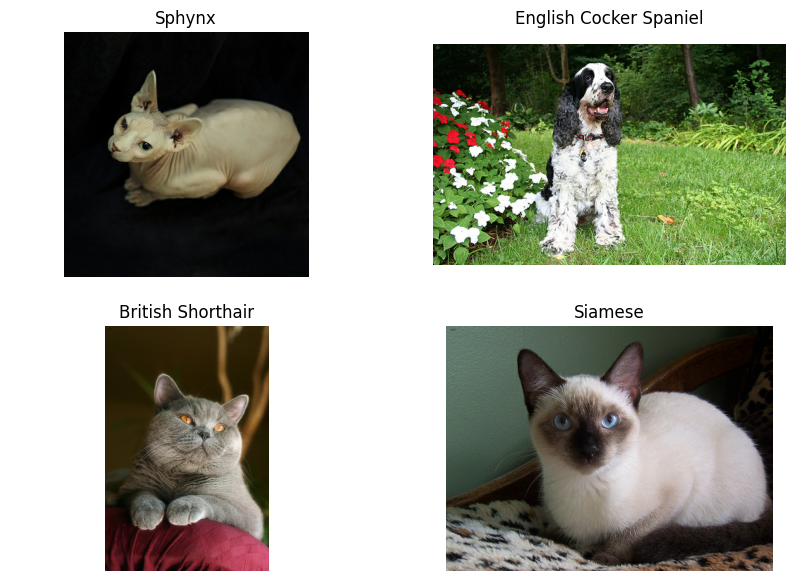

In [3]:
# Retrieve the class label names
class_label = info.features['label'].names

# Define width and height of figure in inches
fig = plt.figure(figsize=(10, 7))

for i, (image, label) in enumerate(dataset.take(4)):

    # Subplot of 2 rows, 2 columns and in specified position
    plt.subplot(2, 2, i + 1) 
    plt.imshow(image)
    plt.axis('equal')
    plt.axis('off')

    # Define the name of the pet
    pet_label = class_label[label.numpy()]
    pet_label_split = pet_label.split("_")
    pet_label_capitalize = [word[0].upper() + word[1:] for word in pet_label_split]
    pet_name = " ".join(pet_label_capitalize)
    plt.title(pet_name)

### Plot data from the Abalone dataset

In [4]:
df = pd.read_csv("abalone.csv")

print("\nFeatures:", df.columns.tolist())


Features: ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']


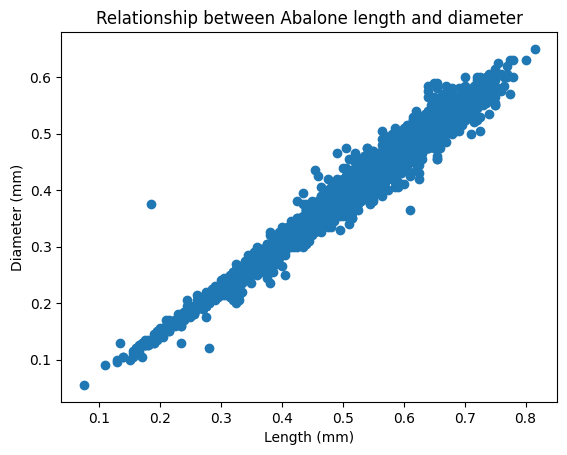

In [5]:
# Scatterplot
x = df['Length']
y = df['Diameter']

plt.scatter(x, y)

plt.xlabel("Length (mm)")
plt.ylabel("Diameter (mm)")
plt.title("Relationship between Abalone length and diameter")

plt.show()

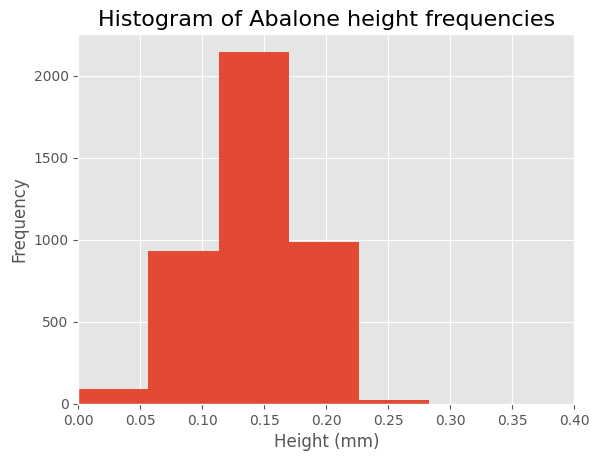

In [6]:
# Histogram
x = df['Height']

with plt.style.context("ggplot"):
    plt.hist(x, bins=20)

    plt.xlim(0.0, 0.4)
    plt.xlabel('Height (mm)')
    plt.ylabel('Frequency')
    plt.title("Histogram of Abalone height frequencies", fontsize=16)

    plt.show()

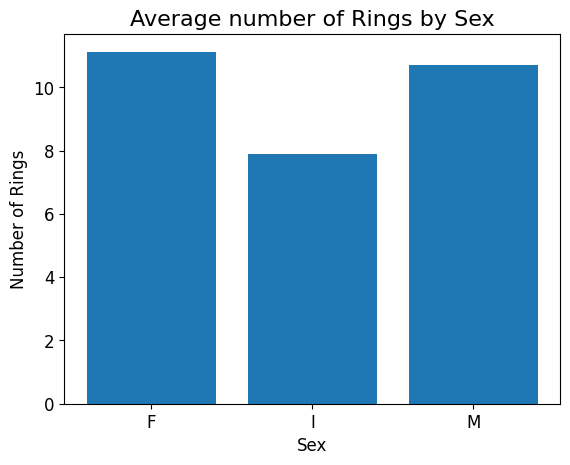

In [7]:
# Bar graph
grouped_data = df.groupby('Sex')['Rings'].mean()

x = grouped_data.index
y = grouped_data.values

with plt.style.context({'font.size': 12}):
    plt.bar(x, y)

    plt.xlabel("Sex")
    plt.ylabel("Number of Rings")
    plt.title("Average number of Rings by Sex", fontsize=16)

    plt.show()



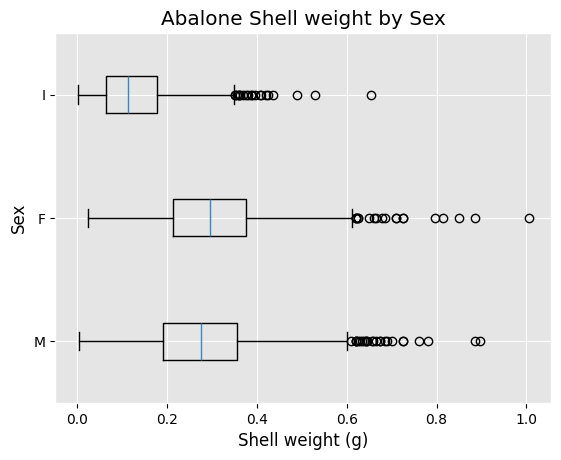

In [8]:
# Boxplot
male = df[df['Sex'] == 'M']['Shell weight']
female = df[df['Sex'] == 'F']['Shell weight']
infant = df[df['Sex'] == 'I']['Shell weight']
gender_groups = [male, female, infant]

with plt.style.context(['ggplot', {
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    }]):
    plt.boxplot(gender_groups, tick_labels=["M", "F", "I"], vert=False)

    plt.xlabel("Shell weight (g)")
    plt.ylabel("Sex")
    plt.title("Abalone Shell weight by Sex")

    plt.show()

# Seaborn

Seaborn allows for easier grouping of variables with the 'hue' parameter.

In [9]:
# Load a sample dataset
tips = sns.load_dataset("tips")
print(tips.head())
print("\nFeatures:", tips.columns.tolist())
print("\nDimensions of the data:", tips.shape)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Features: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Dimensions of the data: (244, 7)


### Line Plot

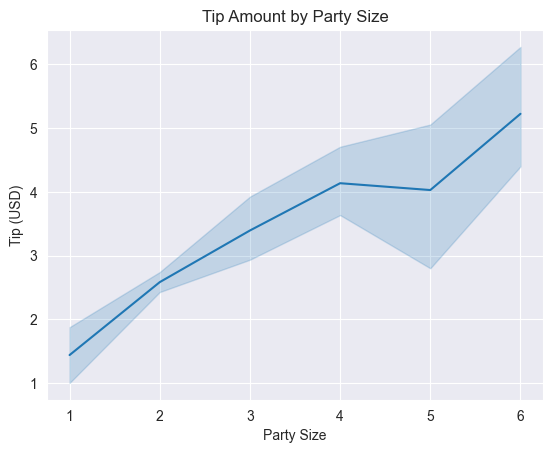

In [10]:
# Set Seaborn style to darkgrid
sns.set_style("darkgrid")

# Shaded area shows 95% confidence interval
sns.lineplot(x="size", y="tip", data=tips)
plt.title("Tip Amount by Party Size")
plt.ylabel("Tip (USD)")
plt.xlabel("Party Size");


### KDE Plots

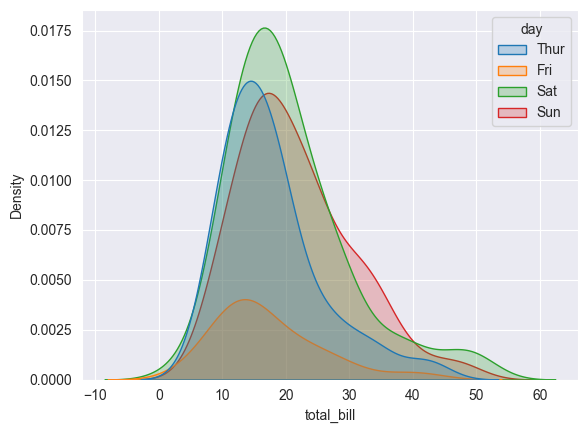

In [11]:
# Univariate KDE plot
sns.kdeplot(data=tips, x="total_bill", hue="day", fill=True);


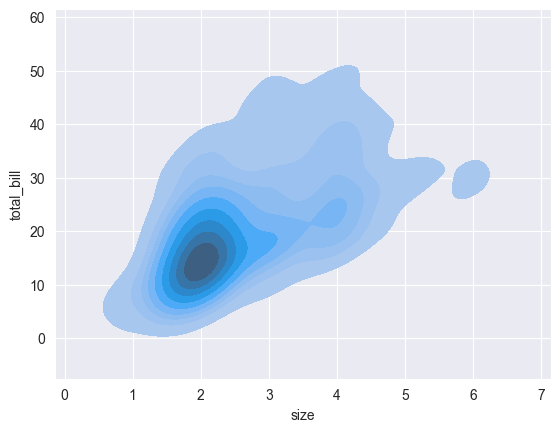

In [12]:
# Bivariate KDE plot 
sns.kdeplot(data=tips, x="size", y="total_bill", fill=True);

Kernel Density Function (KDE) plots allow us to estimate the probability density function from our dataset. For univariate KDE plots, the density of all possible x values (total_bill) are denoted. While for bivariate KDE plots, the density of every possible x and y pair (size, total_bill) is shown.


### ECDF Plots

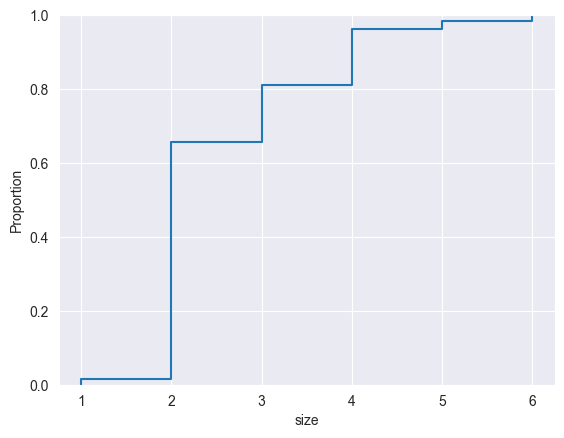

In [13]:
# ECDF plot 
sns.ecdfplot(data=tips, x="size");


Empirical Cumulative Distribution Function (ECDF) plots are used to look at the distribution of our data. These plots show cumulative distributions, involving the proportion of each x axis quantity (size) being observed.

We can also apply categories to this plot type via the hue parameter:

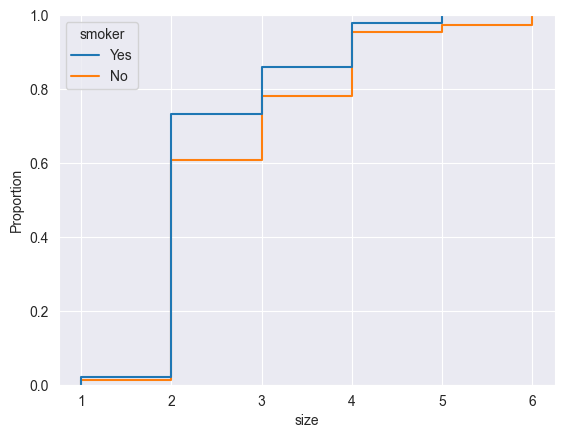

In [14]:
# ECDF plot with two categories
sns.ecdfplot(data=tips, x="size", hue="smoker");


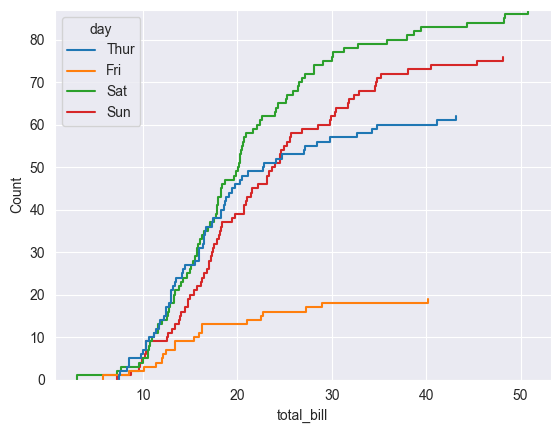

In [15]:
# ECDF plot showing counts
sns.ecdfplot(data=tips, x="total_bill", hue="day", stat="count");

### Violin Plot

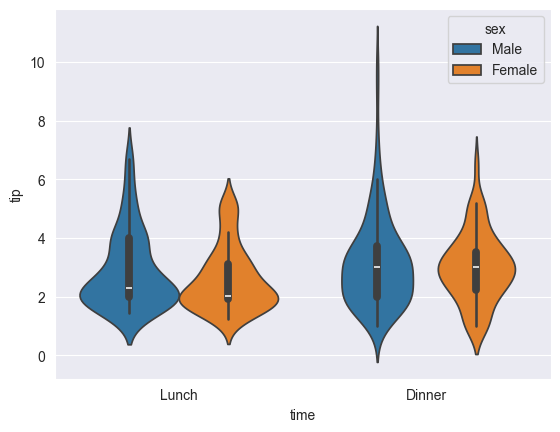

In [16]:
# Violin Plots combine boxplots and KDE plots
sns.violinplot(data=tips, x="time", y="tip", hue="sex", bw_method=0.4);

### Heatmap

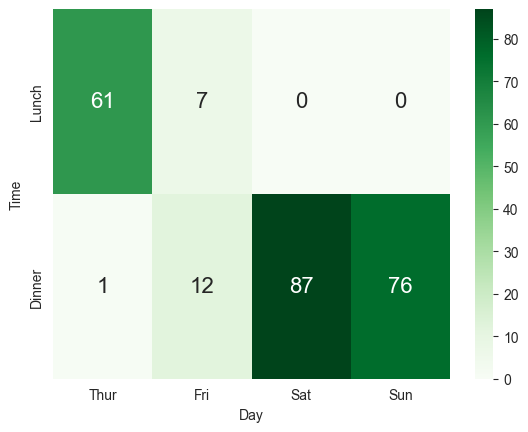

In [17]:
# Heatmap to show commonly observed eating times during different days
day_time_tips = (tips
 .groupby("day", observed=True)
 .time
 .value_counts()
 .unstack()
 .fillna(0)
)
ax = sns.heatmap(
    day_time_tips.T, 
    cmap="Greens",
    annot=True,
    annot_kws={'fontsize': 16}
    )
ax.set_xlabel("Day")
ax.set_ylabel("Time");

In [18]:
# Load the iris dataset
iris = sns.load_dataset("iris")
print(iris.head())
print("\nFeatures:", iris.columns.tolist())
print("\nDimensions of the data:", iris.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Dimensions of the data: (150, 5)


### PairGrid
Pairgrids are used to display small multiples of every pairwise relationship in the dataset.

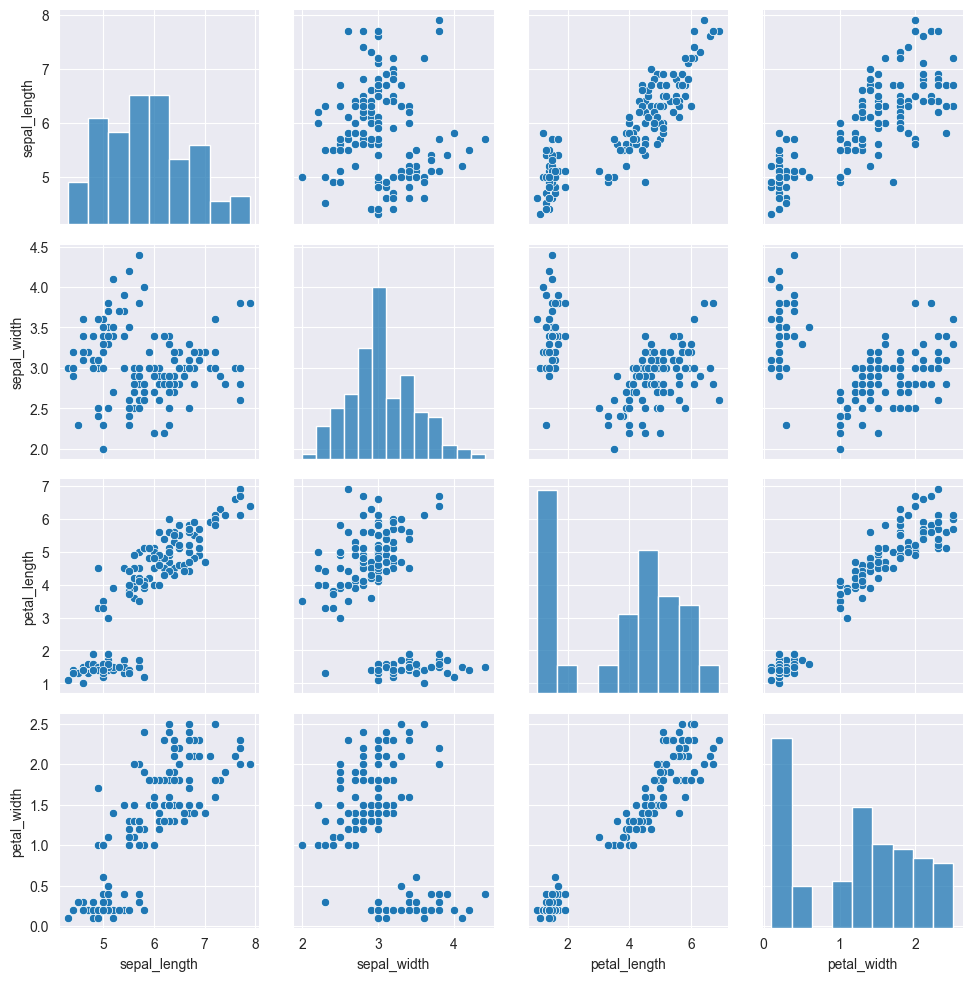

In [19]:
# PairGrid of iris dataset variables
g = sns.PairGrid(iris)
g.map_offdiag(sns.scatterplot)
g.map_diag(sns.histplot);

### Facet Grid
Facet Grid is used to display small multiples of the specified variables.

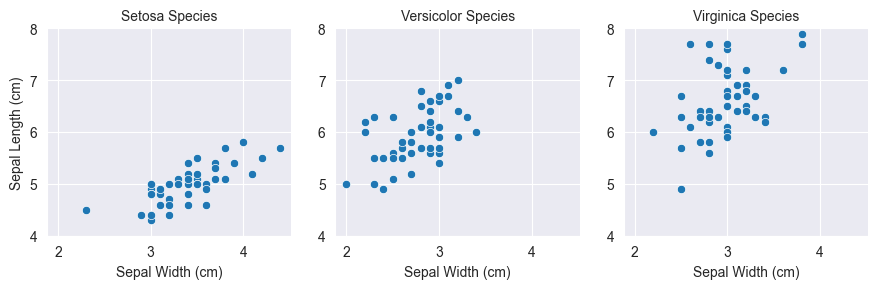

In [20]:
# Facet Grid of scatterplots
iris["species"] = iris["species"].str.capitalize()
g = sns.FacetGrid(data=iris, col="species", sharey=False, ylim=(4, 8))
g.map_dataframe(sns.scatterplot, x="sepal_width", y="sepal_length")
g.set_axis_labels("Sepal Width (cm)", "Sepal Length (cm)")
g.set_titles(col_template="{col_name} Species");